# ANDES Demonstration of SESS on IEEE 39-Bus System

## Simulation Setup

The IEEE 39-Bus System is derived from MATPOWER data. All generators are modeled as `GENCLS`, with no turbine governors, exciters, or power system stabilizers included.

We simulate a **short circuit at bus 4 lasting 0.1 seconds**, comparing two scenarios:

- Without any `SESS`
- With **two `SESS` units placed at buses 10 and 20**

## Analysis

We analyze the **center-of-inertia (COI) frequency** `omega` for both cases and compare the **integrals under the resulting curves**.

The **power outputs of the `SESS`** units are also presented.

In [1]:
import andes
from andes.utils.paths import get_case
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

andes.config_logger(stream_level=30)
%matplotlib inline

In [2]:
# Load the initial system configuration
casedata = get_case("ieee39/case39_gencls.xlsx")
s0 = andes.load(casedata, setup=False, no_output=True)
s1 = andes.load(casedata, setup=False, no_output=True)


In [3]:
# Add short circuit at bus 4 and set damping D = 2
for ss in [s0, s1]:
    ss.GENCLS.D.v = len(ss.GENCLS.D.v) * [2]
    ss.add(model="Fault", bus=4, tf=1.0, tc=1.1)

In [4]:
# Add bus frequency measurements and place SESS units at buses 10 and 20
Pmax = 0.3
for b in [10, 20]:
    s1.add(model="BusFreq", idx=f"f{b}", bus=b, Tf=0.02, Tw=0.5, fn=60)
    s1.add(
        u=1,
        model="SESS",
        idx=f"SESS{b}",
        bus=b,
        dbf=0.02/60,
        Tf=0.02,
        T1=0.5,
        T2=3.0,
        K=Pmax/0.003, # 0.003 pu change in f gives Pmax,
        T=0.026,
        Pmin=-Pmax,
        Pmax=Pmax,
    )
print("Bus frequency measurement devices:")
display(s1.BusFreq.as_df())

print("\nSimple Energy Storage Systems:")
display(s1.SESS.as_df())

Bus frequency measurement devices:


,idx,u,name,bus,Tf,Tw,fn
uid,,,,,,,
0,f10,1,f10,10,0.02,0.5,60
1,f20,1,f20,20,0.02,0.5,60



Simple Energy Storage Systems:


,idx,u,name,bus,busf,dbf,Tf,T1,T2,K,T,Pmax,Pmin
uid,,,,,,,,,,,,,
0,SESS10,1,SESS10,10,None,0.000333,0.02,0.5,3.0,100.0,0.026,0.3,-0.3
1,SESS20,1,SESS20,20,None,0.000333,0.02,0.5,3.0,100.0,0.026,0.3,-0.3


In [5]:
# Run simulations for both scenarios
t = []
omegaCOI = []
for ss in [s0, s1]:
    ss.setup()
    ss.PFlow.run()
    ss.TDS.config.no_tqdm = 1  # turn off the progress bar
    ss.TDS.config.tf = 60.0  # simulation time
    ss.TDS.config.criteria = 0  # turn off the criteria check
    ss.PQ.config.p2z = 1.0
    ss.PQ.config.q2z = 1.0
    ss.TDS.run()
    t.append(ss.dae.ts.t)
    omegaCOI.append(ss.dae.ts.y[:, ss.COI.omega.a[0]])


<Fault Fault_1>: Applying fault on Bus (idx=4) at t=1.0 sec.
<Fault Fault_1>: Clearing fault on Bus (idx=4) at t=1.1 sec.
<Fault Fault_1>: Applying fault on Bus (idx=4) at t=1.0 sec.
<Fault Fault_1>: Clearing fault on Bus (idx=4) at t=1.1 sec.


Area: A(0) = 0.0393
Area: A(1) = 0.0238
Ratio of areas: A(0)/A(1) = 1.6499


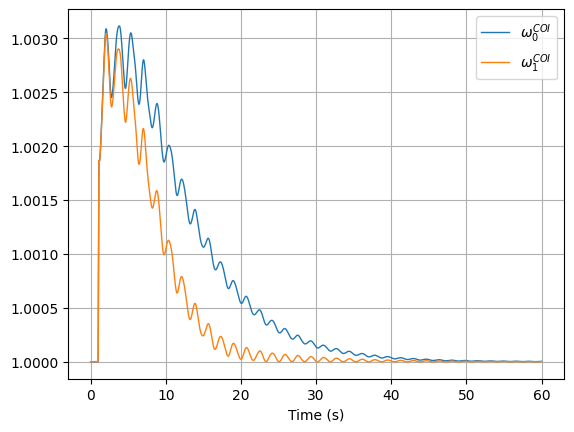

In [6]:
# Plot COI frequency and calculate the area under the curves
A = {}
for i, (x, y) in enumerate(zip(t, omegaCOI)):
    plt.plot(x, y, linewidth=1, label=f"$\\omega_{i}^{{COI}}$")
    A[i] = np.trapz(np.abs(y - 1), x)
    print(f"Area: A({i}) = {A[i]:.4f}")
print(f"Ratio of areas: A(0)/A(1) = {A[0]/A[1]:.4f}")
plt.xlabel("Time (s)")
plt.grid()
plt.legend()
plt.show()

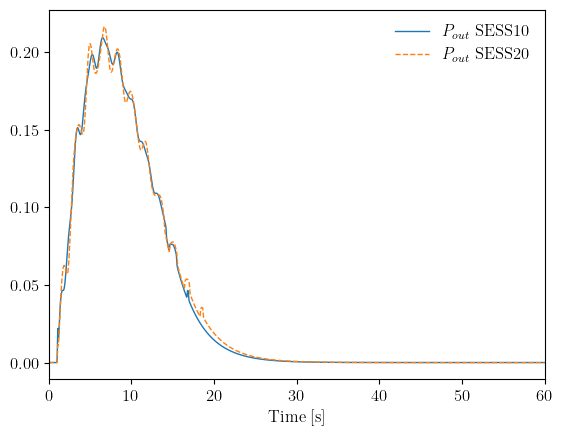

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [7]:
# Plot the power output of the SESS units
s1.TDS.plt.plot(s1.SESS.Pout)